In [1]:
# Import libraries
import pickle
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp 
import matplotlib.pyplot as plt
import anndata
from anndata import AnnData

# For plotting
import seaborn as sns

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# For umap
import umap

# SCVI
import scvi
import cellxgene_census
import cellxgene_census.experimental

# For ML training
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from scipy.sparse import issparse, vstack

/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/home/aoku/.local/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
import scvi

In [3]:
# Load path (path contains seurat object with our annotations)
czi_path = "/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/62_harmony_102224_Seuratv34_newannot_counts.h5ad"

# Read the h5ad file
adata = sc.read_h5ad(czi_path)

print(adata)

AnnData object with n_obs × n_vars = 171459 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

In [4]:
# Get counts data (scVi requires count info)
adata.layers["counts"] = adata.raw.X.copy()
adata.layers["logcounts"] = adata.X.copy()

In [5]:
# Add HECA annotations to adata (annotation from published HECA dataset)
heca_annot = pd.read_csv("/nfs/home/rfu/projects/CZI_endom/CZI_HECAtype.csv.gz")

# Check if cell index matches
print(pd.Series(adata.obs_names == heca_annot.cell).value_counts())

# Add to anndata
adata.obs["heca_celltype"] = heca_annot["celltype"].values
adata.obs["heca_lineage"] = heca_annot["lineage"].values

True    171459
Name: count, dtype: int64


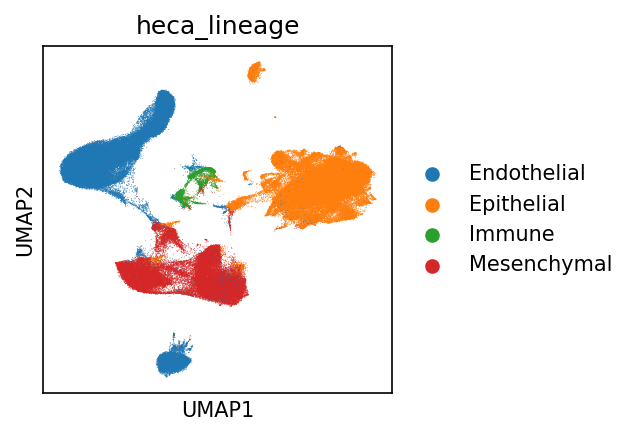

In [6]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata, color='heca_lineage')

In [7]:
# Prep data for scVI
#Get ensembl IDs - map gene symbol to ensembl ID
gene_ids = pd.read_csv("/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/gene_names_gene_ids_czi_endo.csv", index_col= False)

gene_id_dict = pd.DataFrame({
    'gene_symbol': gene_ids["gene_name"],
    'ensembl_id': gene_ids["gene_id"]})

gene_id_dict = gene_id_dict.set_index('gene_symbol')['ensembl_id'].to_dict()

ensembl_ids = [gene_id_dict.get(gene, 'NA') for gene in adata.var_names]

# Add ensembl IDs to anndata object
adata.var["gene_names"] = adata.var_names
adata.var["ensembl_id"] = ensembl_ids
adata.var_names = ensembl_ids

# Remove duplicated IDs
adata = adata[:, ~adata.var["ensembl_id"].duplicated()].copy()

# Check for duplicated IDs
adata.var["ensembl_id"].duplicated().any()

del adata.varm["HARMONY"]
del adata.varm["PCs"]

#### Split data into training and testing sets

In [8]:
# Get unique sample IDs
unique_ids = adata.obs['id'].unique()

# Split the sample IDs
train_ids, test_ids = train_test_split(unique_ids, test_size=0.15, random_state=42)

# Create boolean masks
train_mask = adata.obs['id'].isin(train_ids)
test_mask = adata.obs['id'].isin(test_ids)

# Subset the AnnData object
adata_train = adata[train_mask].copy()
adata_test = adata[test_mask].copy()

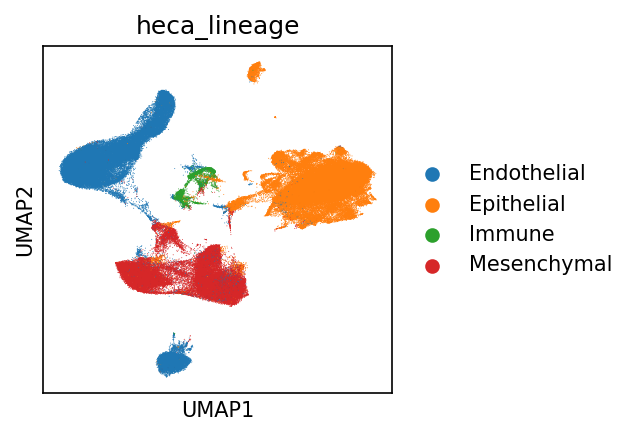

In [9]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata_train, color='heca_lineage')

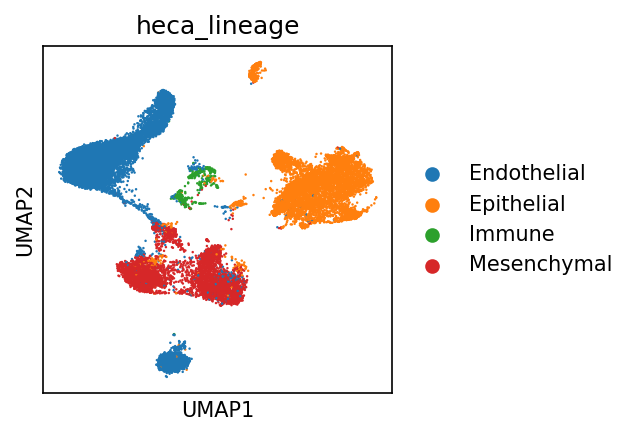

In [10]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata_test, color='heca_lineage')

In [11]:
print(adata)

AnnData object with n_obs × n_vars = 171459 × 36592
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

In [13]:
import anndata
import pandas as pd
import numpy as np
from sklearn.utils import check_random_state
import warnings

def create_proportional_pseudobulks(
    adata: anndata.AnnData,  # anndata object from a single sample
    cell_type_col: str,      # column name corresponding to the cell type
    n_pseudobulks: int = 1000,
    target_proportion_min: float = 0.1,
    target_proportion_max: float = 0.9,
    n_cells_per_pseudobulk: int = 800, # Fixed number of cells per pseudobulk
    random_state: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame]:

    # --- Input Validation ---
    if cell_type_col not in adata.obs.columns:
        raise ValueError(f"Cell type column '{cell_type_col}' not found in adata.obs.")
    if not (0 <= target_proportion_min < target_proportion_max <= 1):
        raise ValueError("target_proportion_min must be less than target_proportion_max, "
                         "and both must be between 0 and 1.")
    if not (n_cells_per_pseudobulk > 0):
        raise ValueError("n_cells_per_pseudobulk must be greater than 0.")

    # --- Setup ---
    rng = check_random_state(random_state)
    all_cell_types = adata.obs[cell_type_col].unique()
    
    # Check if there are at least two cell types to allow for "other" cells
    if len(all_cell_types) < 2 and (target_proportion_max < 1.0 or target_proportion_min > 0.0):
        warnings.warn("Less than 2 unique cell types found. Proportional mixing might be limited "
                      "if target_proportion_min is not 0.0 or target_proportion_max is not 1.0.")
    elif len(all_cell_types) < 1:
        warnings.warn("No cell types found in adata.obs. Returning empty DataFrames.")
        return pd.DataFrame(), pd.DataFrame()

    pseudobulk_data_list = []
    proportions_data_list = []
    pseudobulk_sample_names = []

    # Generate random target proportions
    target_proportions = rng.uniform(low=target_proportion_min, high=target_proportion_max, size=n_pseudobulks)
    
    # Cycle through cell types to be the 'target'
    cell_type_cycle = np.tile(all_cell_types, int(np.ceil(n_pseudobulks / len(all_cell_types))))[:n_pseudobulks]

    # Group cells by cell type for efficient sampling
    grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()

    # --- Create multiple pseudobulks based on controlled proportions ---
    for i in range(n_pseudobulks):
        target_cell_type = cell_type_cycle[i]
        current_target_prop = target_proportions[i]

        # Calculate cell counts for target and other cells
        n_target_cells = int(np.round(n_cells_per_pseudobulk * current_target_prop))
        n_target_cells = max(0, min(n_target_cells, n_cells_per_pseudobulk)) # Ensure within bounds

        n_other_cells = n_cells_per_pseudobulk - n_target_cells

        selected_indices = []

        # 1. Sample Target Cell Type
        if target_cell_type in grouped_cells and len(grouped_cells[target_cell_type]) > 0:
            if n_target_cells > 0:
                target_cell_indices = rng.choice(
                    grouped_cells[target_cell_type],
                    size=n_target_cells,
                    replace=True # Allow replacement to hit exact proportions, even if few cells
                ).tolist()
                selected_indices.extend(target_cell_indices)
        elif n_target_cells > 0:
            warnings.warn(f"Cell type '{target_cell_type}' selected as target for PB_{i+1}, "
                          f"but has no cells. This pseudobulk will have 0% of '{target_cell_type}'.")
            # This pseudobulk will just consist of 'other' cells if target has no cells.

        # 2. Sample "Other" Cell Types
        if n_other_cells > 0:
            other_cell_types = [ct for ct in all_cell_types if ct != target_cell_type]
            
            if len(other_cell_types) > 0:
                # Get all indices of 'other' cell types
                all_other_indices = []
                for ct in other_cell_types:
                    if ct in grouped_cells and len(grouped_cells[ct]) > 0:
                        all_other_indices.extend(grouped_cells[ct])
                
                if len(all_other_indices) > 0:
                    other_cell_selected_indices = rng.choice(
                        all_other_indices,
                        size=n_other_cells,
                        replace=True # Allow replacement for 'other' cells
                    ).tolist()
                    selected_indices.extend(other_cell_selected_indices)
                else:
                    warnings.warn(f"No 'other' cell types available for sampling for PB_{i+1}. "
                                  f"This pseudobulk might consist solely of the target type or be empty.")
            elif n_target_cells == 0: # If no other cell types and no target cells selected
                 warnings.warn(f"No cells available to sample for PB_{i+1}. Skipping this pseudobulk.")
                 continue # Skip to next pseudobulk if no cells can be sampled

        # Handle cases where selected_indices might be empty (e.g., if n_cells_per_pseudobulk is 0 or no cells available)
        if not selected_indices:
            warnings.warn(f"No cells sampled for pseudobulk PB_{i+1}. Skipping this pseudobulk.")
            continue

        # Store the pseudobulk expression
        pb_expression_matrix = adata[selected_indices, :].X
        if isinstance(pb_expression_matrix, (np.ndarray, pd.DataFrame)):
            pb_expression_sum = pb_expression_matrix.sum(axis=0)
        else: # Assume sparse matrix (e.g., scipy.sparse.csr_matrix)
            pb_expression_sum = pb_expression_matrix.sum(axis=0).A1 

        pseudobulk_data_list.append(pb_expression_sum)

        # Calculate and store the actual cell type proportions
        selected_cell_types_series = adata.obs.loc[selected_indices, cell_type_col]
        current_pb_counts = selected_cell_types_series.value_counts()
        current_pb_proportions = current_pb_counts / current_pb_counts.sum()

        proportions_dict = {ct: 0.0 for ct in all_cell_types}
        for ct, prop in current_pb_proportions.items():
            proportions_dict[ct] = prop
        proportions_data_list.append(proportions_dict)

        # Generate a unique name for the pseudobulk sample
        pseudobulk_sample_names.append(f"{target_cell_type}_PB{i+1}")
                
    # --- Create final DataFrames ---
    if not pseudobulk_data_list:
        warnings.warn("No pseudobulk samples were successfully created. Returning empty DataFrames.")
        return pd.DataFrame(), pd.DataFrame()

    pseudobulk_df = pd.DataFrame(
        pseudobulk_data_list,
        index=pseudobulk_sample_names,
        columns=adata.var_names
    )

    proportions_df = pd.DataFrame(
        proportions_data_list,
        index=pseudobulk_sample_names
    )
    # Ensure all_cell_types are columns, filling missing with 0 for consistency
    proportions_df = proportions_df.reindex(columns=all_cell_types, fill_value=0.0)

    return pseudobulk_df, proportions_df

### Get Pseudobulk data

In [14]:
all_pseudobulks = []
all_cell_props = []
id_list = ['B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N']

for sample_id in id_list:
    adata_sub = adata_train[adata_train.obs["id"] == sample_id].copy()
    if adata_sub.n_obs == 0:
        print(f"No cells found for ID: {sample_id}")
        continue

    pseudobulk_czi_temp, pseudobulk_czi_cell_prop_temp = create_proportional_pseudobulks(
        adata=adata_sub,
        cell_type_col="heca_lineage",
        n_cells_per_pseudobulk=800, random_state=42
    )

    all_pseudobulks.append(pseudobulk_czi_temp)
    all_cell_props.append(pseudobulk_czi_cell_prop_temp)

# Concatenate all results
pseudobulk_czi = pd.concat(all_pseudobulks, axis=0, ignore_index=True)
pseudobulk_czi_cell_prop = pd.concat(all_cell_props, axis=0, ignore_index=True)

/tmp/ipykernel_554510/2049627862.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()
/tmp/ipykernel_554510/2049627862.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()
/tmp/ipykernel_554510/2049627862.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of panda

In [15]:
print(pseudobulk_czi.shape)
print(pseudobulk_czi.iloc[0:6, 0:6])
print(pseudobulk_czi.shape)

(3000, 36592)
   ENSG00000243485  ENSG00000237613  ENSG00000186092  ENSG00000238009  \
0              0.0              0.0              0.0              3.0   
1              0.0              0.0              0.0              0.0   
2              0.0              0.0              0.0              3.0   
3              0.0              0.0              0.0              3.0   
4              0.0              0.0              0.0              4.0   
5              0.0              0.0              0.0              2.0   

   ENSG00000239945  ENSG00000239906  
0              0.0              0.0  
1              0.0              0.0  
2              0.0              0.0  
3              1.0              0.0  
4              0.0              0.0  
5              0.0              0.0  
(3000, 36592)


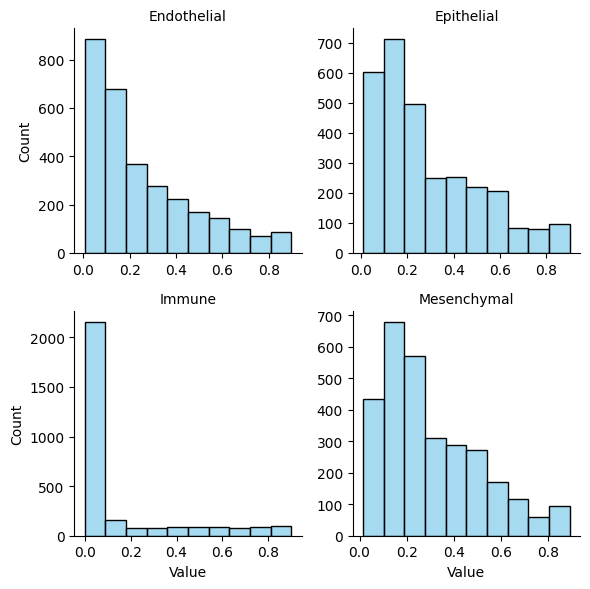

In [17]:
# Explore cell type proportions
# Reshape the data to long format
df_long = pseudobulk_czi_cell_prop.melt(var_name='Variable', value_name='Value')

# Create facet plot
g = sns.FacetGrid(df_long, col='Variable', col_wrap=2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Value', bins=10, color='skyblue')

# Adjust layout
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
plt.tight_layout()
plt.show()

## scVI

In [88]:
# convert bulk to anndata
X = pseudobulk_czi  # Now rows = samples, columns = genes

# Create AnnData object
adata_bulk = anndata.AnnData(X)

# Set sample names and gene names
adata_bulk.obs_names = X.index     
adata_bulk.var_names = X.columns 

# Add batch information
adata_bulk.obs["batch"] = ['B2-CZI08N'] * 1000 + ['B3-CZI11N'] * 1000 + ['B3-CZI05N'] * 1000 
adata_bulk.obs["id"] = X.index 


/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [126]:
# Train on single cell data
id_list = ['B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N']
adata_train = adata[adata.obs["id"].isin(id_list)].copy()

In [127]:
scvi.settings.seed = 0

[rank: 0] Seed set to 0


In [128]:
# Set up scVI model
scvi.model.SCVI.setup_anndata(
    adata_train,
    #layer="counts",
    categorical_covariate_keys=["id"]
)

# Set upn model with 100 dimensions
scvi_model = scvi.model.SCVI(adata_train, n_latent = 500)

In [129]:
print(scvi_model)

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 500, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [130]:
scvi_model.train()

/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nfs/home/aoku/.local/lib/python3.10/site-packages/i ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nfs/home/aoku/.local/lib/python3.10/site-packages/i ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers whi

Epoch 400/400: 100%|██████████| 400/400 [05:39<00:00,  1.17it/s, v_num=1, train_loss_step=7.32e+3, train_loss_epoch=6.37e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [05:39<00:00,  1.18it/s, v_num=1, train_loss_step=7.32e+3, train_loss_epoch=6.37e+3]


In [131]:
scvi_model.save("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/models/trained_scVI_model_500_n_dim_with_batch_correction")

In [132]:
# # This allows for a simple forward pass
adata_query = scvi.model.SCVI.load_query_data(adata_bulk, scvi_model)

# Get latent embeddings 
adata_query.is_trained = True
latent_czi_pseudobulk = adata_query.get_latent_representation()

/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nfs/home/aoku/.local/lib/python3.10/site-packages/i ...
/nfs/home/aoku/.local/lib/python3.10/site-packages/scvi/data/fields/_arraylike_field.py:410: UserWarning: Category 3 in adata.obs['id'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


In [133]:
# Convert to dataframe
latent_czi_pseudobulk = pd.DataFrame(latent_czi_pseudobulk)
latent_czi_pseudobulk.index = adata_bulk.obs["id"]

In [134]:
# Define X and y 
X = latent_czi_pseudobulk
y = pseudobulk_czi_cell_prop.loc[latent_czi_pseudobulk.index, :]

In [135]:
# Identify missing values
missing_indices = y[y.isna().any(axis=1)].index

# Drop those from both X and y
X = X.drop(index=missing_indices)
y = y.drop(index=missing_indices)

In [136]:
missing_indices

Index([], dtype='int64', name='id')

In [137]:
# Train regressor model
# Split data into training and test splits
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [138]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2400, 500)
(2400, 4)
(600, 500)
(600, 4)


In [139]:
y_train.isna().sum()

Endothelial    0
Immune         0
Mesenchymal    0
Epithelial     0
dtype: int64

In [140]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, random_state=42)

In [141]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

In [142]:
def plot_true_vs_predicted(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5):

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot
        sns.scatterplot(x=x, y=y, alpha=0.7, ax=ax, s=dot_size)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


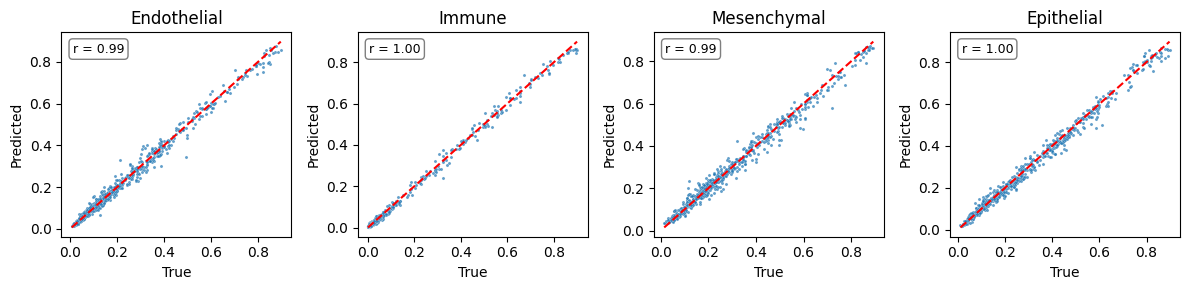

In [143]:
# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

### Use randomly sampled pseudobulk 

In [144]:
adata_test_sample = adata_test[adata_test.obs["id"].isin (["B15-CZI251N"])] #"B5-CZI34N"
#adata_test_sample = adata_train[adata_train.obs["id"].isin(["B3-CZI11N"])]
#["B4P4-CZI04N", "B4P1-CZI01N","B3-CZI05N"]

In [145]:
test_czi, test_czi_cell_prop = create_proportional_pseudobulks(adata=adata_test_sample, cell_type_col="heca_lineage", random_state=42)

/tmp/ipykernel_3823030/2049627862.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()
/tmp/ipykernel_3823030/2049627862.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_cells = adata.obs.groupby(cell_type_col).apply(lambda x: x.index.tolist()).to_dict()


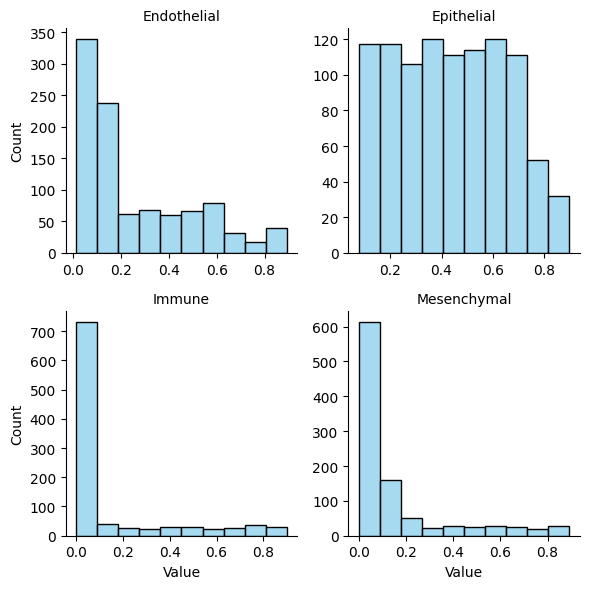

In [146]:
# Explore cell type proportions
# Reshape the data to long format
df_long = test_czi_cell_prop.melt(var_name='Variable', value_name='Value')

# Create facet plot
g = sns.FacetGrid(df_long, col='Variable', col_wrap=2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Value', bins=10, color='skyblue')

# Adjust layout
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
plt.tight_layout()
plt.show()

In [147]:
# convert bulk to anndata
# Create AnnData object
adata_bulk_test = anndata.AnnData(test_czi)

# Set sample names and gene names
adata_bulk_test.obs_names = test_czi.index     
adata_bulk_test.var_names = test_czi.columns 

# Add batch information
adata_bulk_test.obs["batch"] = "czi pseudobulk"
adata_bulk_test.obs["id"] = test_czi.index 

In [148]:
# Loading a model
# scvi_model = scvi.model.SCVI.load("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/models/trained_scVI_model_100_n_dim/",
#                                  adata=adata_train)

In [149]:
# # This allows for a simple forward pass
adata_query = scvi.model.SCVI.load_query_data(adata_bulk_test, scvi_model)

/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nfs/home/aoku/.local/lib/python3.10/site-packages/i ...
/nfs/home/aoku/.local/lib/python3.10/site-packages/scvi/data/fields/_arraylike_field.py:410: UserWarning: Category 3 in adata.obs['id'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


In [150]:
adata_query.is_trained = True
latent_czi_pseudobulk_test = adata_query.get_latent_representation()
latent_czi_pseudobulk_test = pd.DataFrame(latent_czi_pseudobulk_test)

In [151]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model.predict(latent_czi_pseudobulk_test)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns, index=test_czi.index)

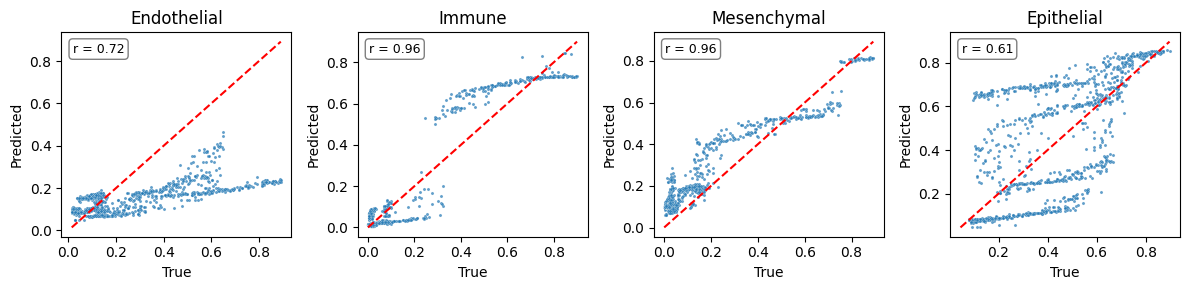

In [152]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)

In [153]:
latent_czi_pseudobulk_test.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_with_batch_corr_dim_500_test_set.csv", index=False)
latent_czi_pseudobulk.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_with_batch_corr_dim_500_train_set.csv", index=False)

### Compare distribution of scVI embeddings gotten from training and test sets 

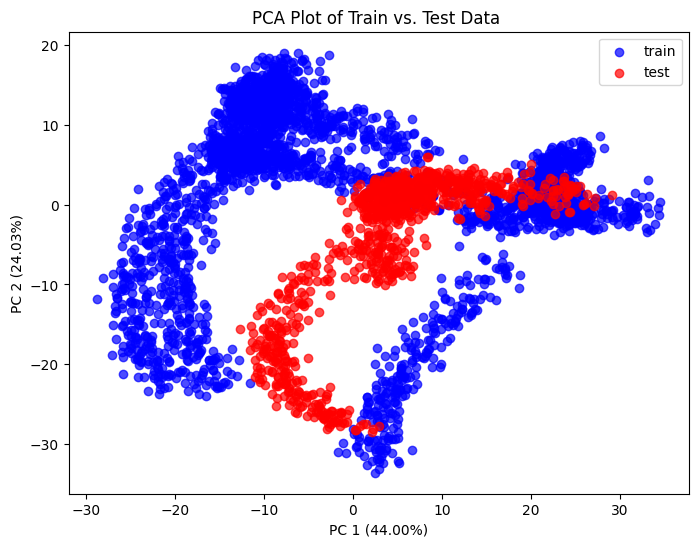

In [154]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming pseudobulk_czi and test_czi are pandas DataFrames with identical columns
# and the shapes you provided: (1000, 36592) and (1000, 36592).

# Step 1: Merge the two dataframes and add a 'source' column
pseudobulk_df_with_source = latent_czi_pseudobulk.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = latent_czi_pseudobulk_test.copy()
test_df_with_source['source'] = 'test'


merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop])

# Step 2: Prepare data for PCA
# The source column needs to be dropped for the PCA calculation
X = merged_df.drop('source', axis=1)

# Step 3: Perform PCA
# We will reduce the dimensionality to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Step 4: Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['source'] = merged_df['source']

# Step 5: Plot the PCA results
plt.figure(figsize=(8, 6))

# Get unique sources for different colors
sources = pca_df['source'].unique()
colors = ['blue', 'red', 'green']  # Or any other color scheme

for i, source in enumerate(sources):
    # Filter the data for each source
    subset = pca_df[pca_df['source'] == source]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=colors[i],
        label=source,
        alpha=0.7
    )

# Add labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot of Train vs. Test Data ')
plt.legend()
plt.grid(False)
plt.show()

### Standardize/Normalize scVI embeddings before training models

In [155]:
from sklearn.preprocessing import StandardScaler

In [156]:
# Define standard scaler
scaler = StandardScaler()

# Scale train set
latent_czi_pseudobulk_z = pd.DataFrame(
    scaler.fit_transform(latent_czi_pseudobulk),
    index=latent_czi_pseudobulk.index,
    columns=latent_czi_pseudobulk.columns
)

# scale test set
latent_czi_pseudobulk_test_z = pd.DataFrame(
    scaler.fit_transform(latent_czi_pseudobulk_test),
    index=latent_czi_pseudobulk_test.index,
    columns=latent_czi_pseudobulk_test.columns
)

# Define X and y 
X = latent_czi_pseudobulk_z
y = pseudobulk_czi_cell_prop.loc[latent_czi_pseudobulk_z.index, :]

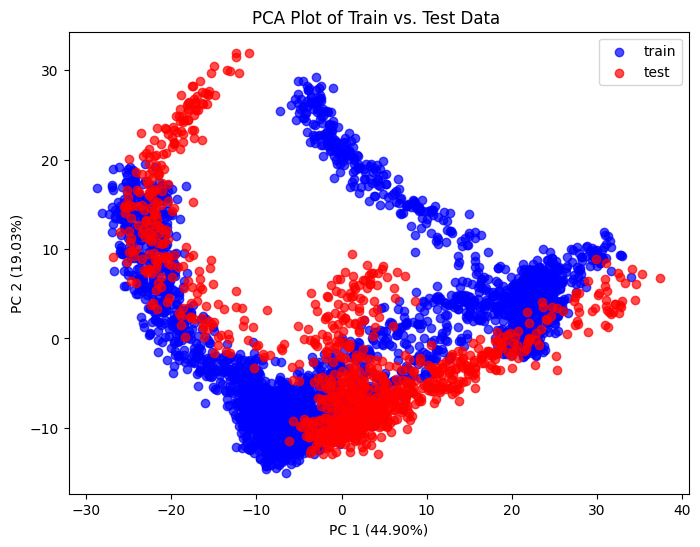

In [157]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming pseudobulk_czi and test_czi are pandas DataFrames with identical columns
# and the shapes you provided: (1000, 36592) and (1000, 36592).

# Step 1: Merge the two dataframes and add a 'source' column
pseudobulk_df_with_source = latent_czi_pseudobulk_z.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = latent_czi_pseudobulk_test_z.copy()
test_df_with_source['source'] = 'test'

#test_df_with_source_2 = test_czi_test.copy()
#test_df_with_source_2['source'] = 'test 2'

merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop])

# Step 2: Prepare data for PCA
# The source column needs to be dropped for the PCA calculation
X_pca = merged_df.drop('source', axis=1)

# Step 3: Perform PCA
# We will reduce the dimensionality to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_pca)

# Step 4: Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['source'] = merged_df['source']

# Step 5: Plot the PCA results
plt.figure(figsize=(8, 6))

# Get unique sources for different colors
sources = pca_df['source'].unique()
colors = ['blue', 'red', 'green']  # Or any other color scheme

for i, source in enumerate(sources):
    # Filter the data for each source
    subset = pca_df[pca_df['source'] == source]
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        c=colors[i],
        label=source,
        alpha=0.7
    )

# Add labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Plot of Train vs. Test Data ')
plt.legend()
plt.grid(False)
plt.show()

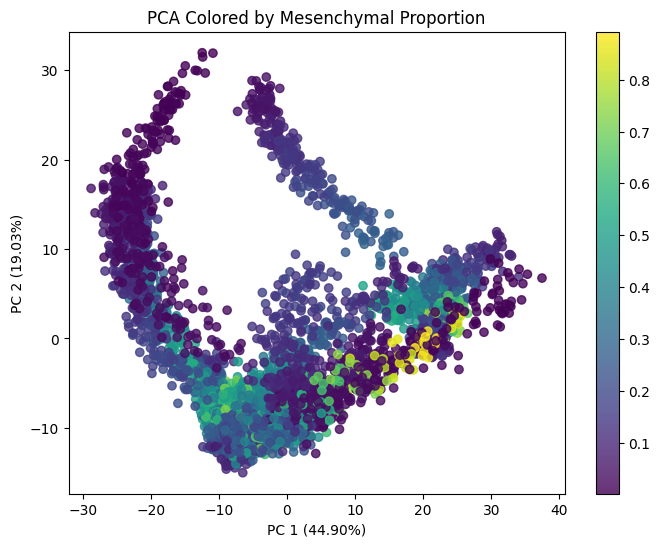

In [158]:
# visualize scaled data
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Merge latent features and add source labels
pseudobulk_df_with_source = latent_czi_pseudobulk_z.copy()
pseudobulk_df_with_source['source'] = 'train'

test_df_with_source = latent_czi_pseudobulk_test_z.copy()
test_df_with_source['source'] = 'test'

merged_df = pd.concat([pseudobulk_df_with_source, test_df_with_source], ignore_index=True)

# Concatenate metadata
metadata_concat = pd.concat([pseudobulk_czi_cell_prop, test_czi_cell_prop], ignore_index=True)

# Ensure metadata index matches merged_df
metadata_concat = metadata_concat.reset_index(drop=True)

# Step 2: Drop 'source' before PCA
X_pca = merged_df.drop('source', axis=1)

# Step 3: PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_pca)

# Step 4: Create PCA DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 5: Add Epithelial values
pca_df['Epithelial'] = metadata_concat['Mesenchymal'].values

# Step 6: Plot PCA, colored by 'Epithelial'
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    c=pca_df['Epithelial'], 
    cmap='viridis', 
    alpha=0.8
)

plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA Colored by Mesenchymal Proportion')
plt.colorbar(scatter, label='')
plt.grid(False)
plt.show()

In [159]:
# Split data into training and test splits (using z score normalized)

# Define X and y 
X = latent_czi_pseudobulk_z
y = pseudobulk_czi_cell_prop.loc[latent_czi_pseudobulk_z.index, :]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

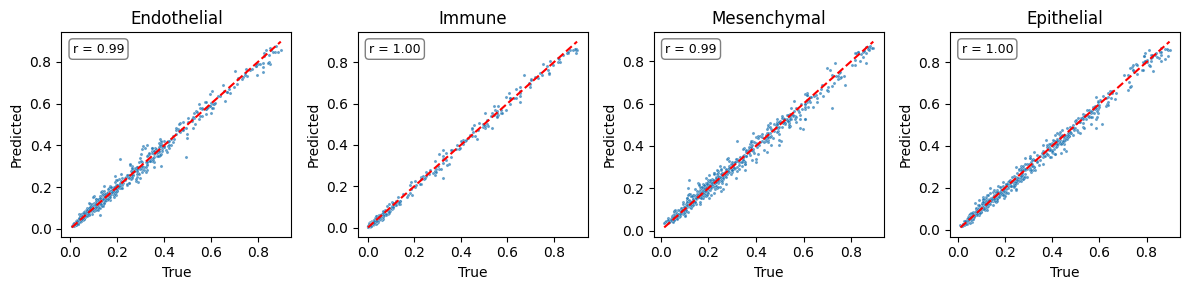

In [160]:
# Train model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

In [161]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model.predict(latent_czi_pseudobulk_test_z)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns, index=test_czi.index)

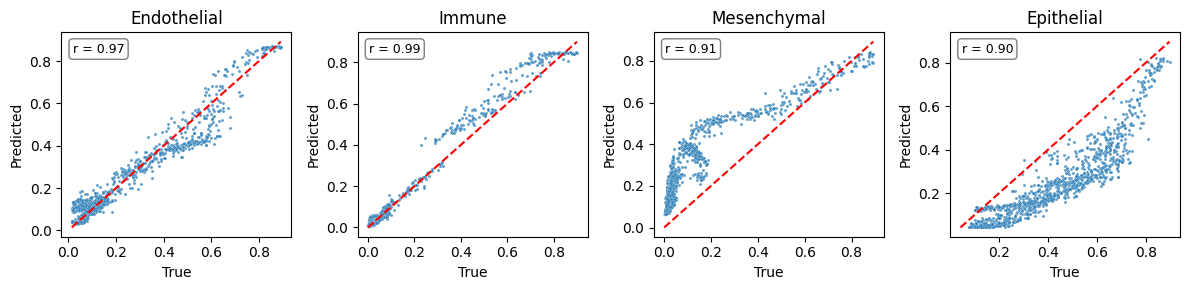

In [162]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)